In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mne matplotlib numpy pandas

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Create a list of data file paths
background_files = [
    '/content/drive/MyDrive/hw2eeg/Subject19_1.edf',
    '/content/drive/MyDrive/hw2eeg/Subject20_1.edf'
]
task_files = [
    '/content/drive/MyDrive/hw2eeg/Subject19_2.edf',
    '/content/drive/MyDrive/hw2eeg/Subject20_2.edf'
]

# Load Raw objects for each condition
raws_background = [mne.io.read_raw_edf(f, preload=True) for f in background_files]
raws_task = [mne.io.read_raw_edf(f, preload=True) for f in task_files]

# Concatenate data from both subjects
raw_background = mne.io.concatenate_raws(raws_background)
raw_task = mne.io.concatenate_raws(raws_task)

# Rename channels and set montage for each Raw object
for raw in [raw_background, raw_task]:
    rename_dict = {
        'EEG Fp1': 'Fp1', 'EEG Fp2': 'Fp2', 'EEG F3': 'F3', 'EEG F4': 'F4',
        'EEG F7': 'F7', 'EEG F8': 'F8', 'EEG T3': 'T3', 'EEG T4': 'T4',
        'EEG C3': 'C3', 'EEG C4': 'C4', 'EEG T5': 'T5', 'EEG T6': 'T6',
        'EEG P3': 'P3', 'EEG P4': 'P4', 'EEG O1': 'O1', 'EEG O2': 'O2',
        'EEG Fz': 'Fz', 'EEG Cz': 'Cz', 'EEG Pz': 'Pz',
        'EEG A2-A1': 'A2',
        'ECG ECG': 'ECG'
    }
    raw.rename_channels(rename_dict)
    raw.set_channel_types({'ECG': 'ecg'})
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'))

print("Data loading and preprocessing from Google Drive complete.")
print("\nInfo for the background condition data:")
print(raw_background.info)
print("\nInfo for the task condition data:")
print(raw_task.info)

Extracting EDF parameters from /content/drive/MyDrive/hw2eeg/Subject19_1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 90999  =      0.000 ...   181.998 secs...
Extracting EDF parameters from /content/drive/MyDrive/hw2eeg/Subject20_1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 90999  =      0.000 ...   181.998 secs...
Extracting EDF parameters from /content/drive/MyDrive/hw2eeg/Subject19_2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...
Extracting EDF parameters from /content/drive/MyDrive/hw2eeg/Subject20_2.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...
Data loading and preprocessing from Google Drive complete.

Info for the background condition data:
<Info | 9 non-empty valu

# a) Plot the power spectral density for the two conditions

Plotting Power Spectral Density (PSD) for the Background Condition...
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
Plotting Power Spectral Density (PSD) for the Task Condition...
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


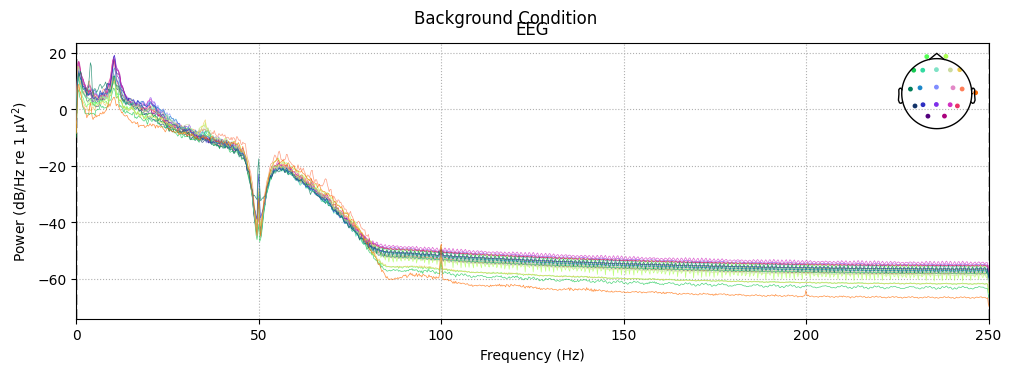

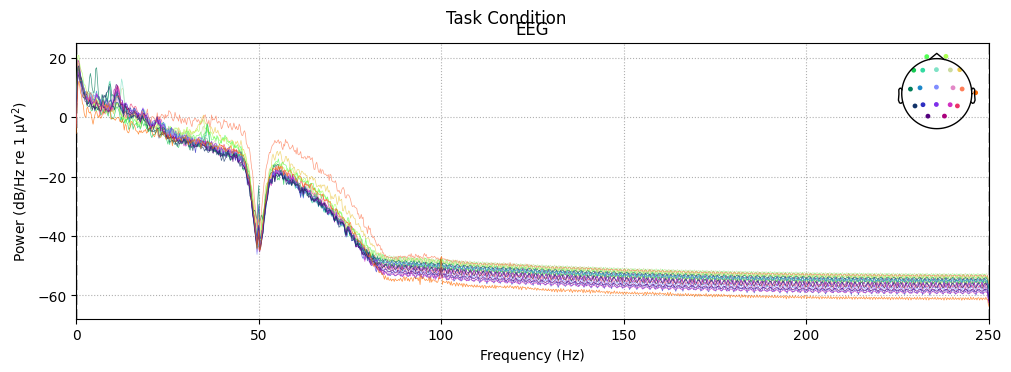

In [ ]:
# Calculate and plot the PSD for the background condition
print("Plotting Power Spectral Density (PSD) for the Background Condition...")
fig_psd_bg = raw_background.compute_psd().plot(show=False)
plt.suptitle('Background Condition', y=1.02)

# Calculate and plot the PSD for the task condition
print("Plotting Power Spectral Density (PSD) for the Task Condition...")
fig_psd_task = raw_task.compute_psd().plot(show=False)
plt.suptitle('Task Condition', y=1.02)

plt.show()

After visualizing the full spectrum, it became clear that the most significant differences between the 'Background' and 'Task' conditions are concentrated in the lower frequency bands. The typical brainwave bands of interest (Alpha, Beta, etc.) all fall below 50 Hz. The higher frequencies show less distinct activity and are more likely to be contaminated by muscle artifacts.

Therefore, to "zoom in" on the key bands and clearly analyze these differences, I will now re-plot the PSD focusing specifically on the 0-50 Hz range.


Plotting the PSD up to 50 Hz for a focused analysis.
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


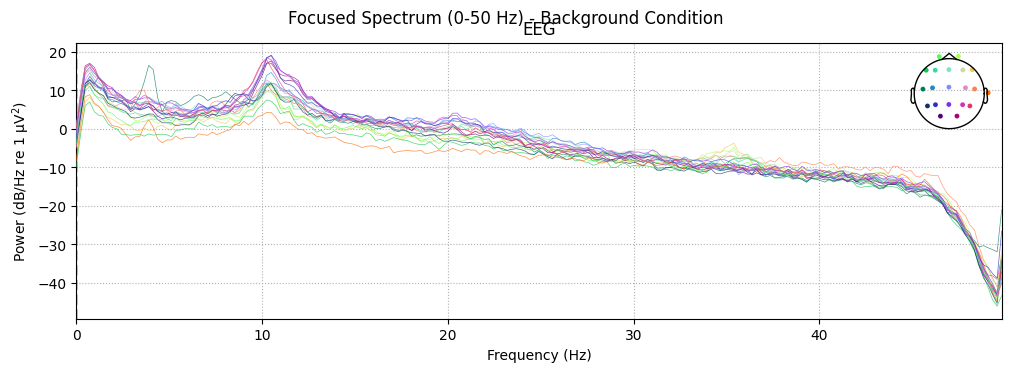

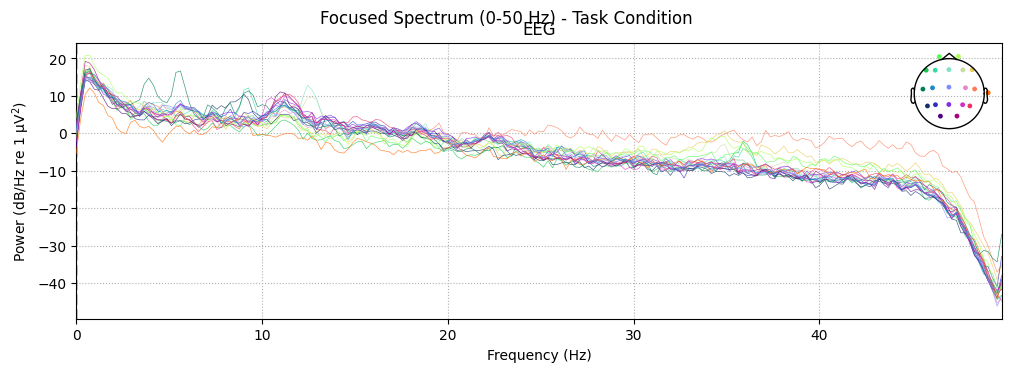

In [ ]:
# Plotting the spectrum up to 50 Hz
print("\nPlotting the PSD up to 50 Hz for a focused analysis.")

# Plot for Background Condition (fmax=50)
fig_psd_bg_50 = raw_background.compute_psd(fmax=50).plot(show=False)
plt.suptitle('Focused Spectrum (0-50 Hz) - Background Condition', y=1.02)

# Plot for Task Condition (fmax=50)
fig_psd_task_50 = raw_task.compute_psd(fmax=50).plot(show=False)
plt.suptitle('Focused Spectrum (0-50 Hz) - Task Condition', y=1.02)

plt.show()

## Results interpretation and discussion
Background Condition: The graph displays a prominent alpha power peak around 10 Hz, which is the typical signature of a brain in a relaxed, resting state.

Task Condition: The strong alpha peak observed during the resting state is significantly diminished.

Conclusion: The most significant difference is the "Alpha Suppression" phenomenon. This clearly indicates the brain shifted from a resting state to an active cognitive state to perform the mental arithmetic task.

# b) Plot the spectrogram for the two conditions

To confirm the differences between the two conditions, I will visualize the spectrogram of the 'Pz' channel. This is because:

1. The preceding PSD analysis in Part (a) identified a significant suppression of the alpha band (8-12 Hz) as the primary difference.

2. A spectrogram will reveal if this alpha suppression is a stable and consistent phenomenon that occurs throughout the entire duration of the task, rather than just an average effect.

3. The 'Pz' channel is located over the parietal lobe, a region where resting-state alpha activity is known to be maximal, making it the ideal location to observe this change clearly.

References:

Hans Op de Beeck and Chie Nakatani, Introduction to human neuroimag-
ing, Cambridge University Press, 2019.

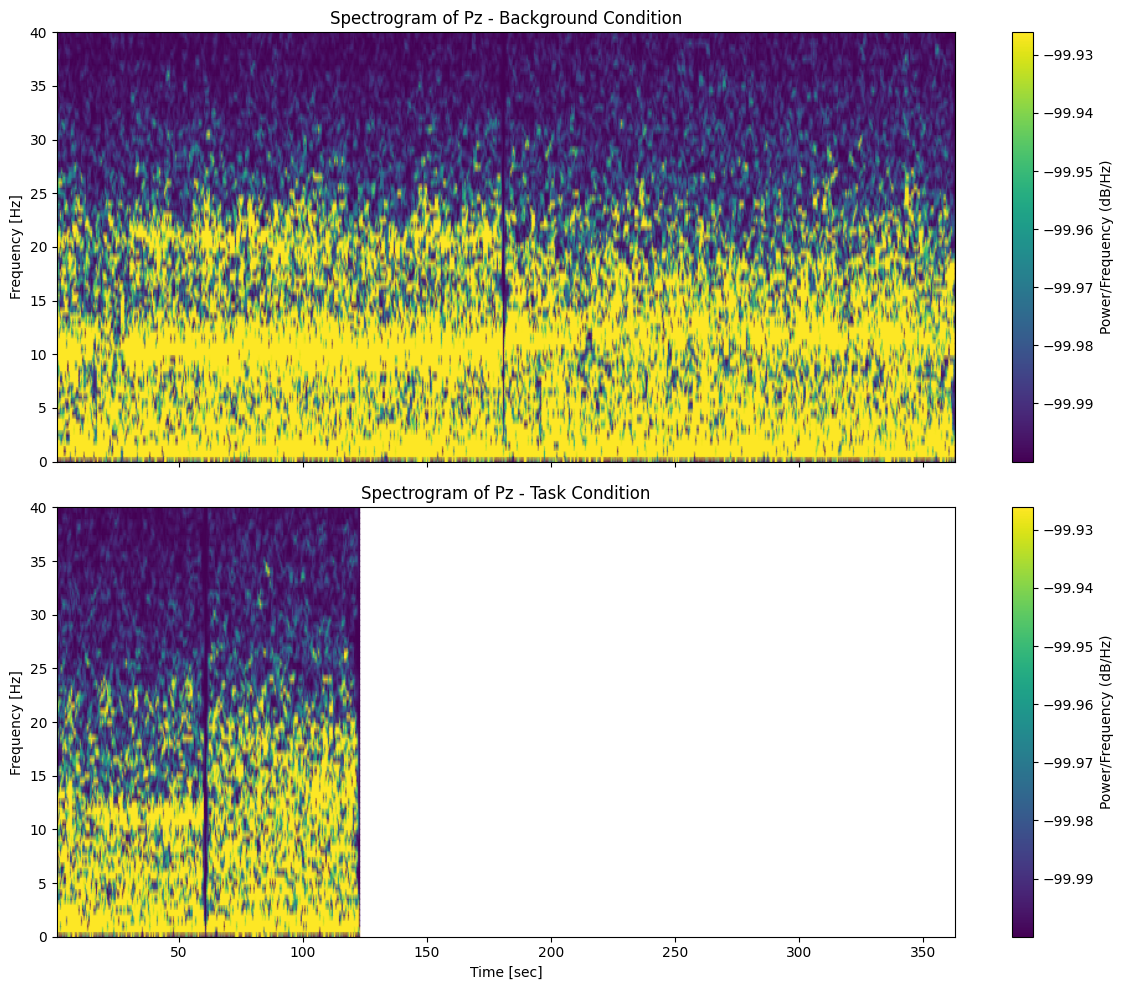

In [ ]:
# Define the channel to plot
channel_to_plot = 'Pz'

# Get the sampling frequency from the data info
sfreq = raw_background.info['sfreq']

# Get the raw data for the selected channel for both conditions
data_background = raw_background.get_data(picks=[channel_to_plot]).squeeze()
data_task = raw_task.get_data(picks=[channel_to_plot]).squeeze()

# Compute the Spectrogram
window_size = int(sfreq * 2) # 2-second window
overlap = int(window_size * 0.75) # 75% overlap

f_bg, t_bg, Sxx_bg = signal.spectrogram(data_background,
                                        fs=sfreq,
                                        nperseg=window_size,
                                        noverlap=overlap)

f_task, t_task, Sxx_task = signal.spectrogram(data_task,
                                              fs=sfreq,
                                              nperseg=window_size,
                                              noverlap=overlap)


# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, sharey=True)

# Convert power to dB (10 * log10(Power)) for better visualization
# Add a small value (1e-10) to avoid log(0) errors
power_db_bg = 10 * np.log10(Sxx_bg + 1e-10)
power_db_task = 10 * np.log10(Sxx_task + 1e-10)

# Find a common min/max for the color scale
all_power_db = np.concatenate((power_db_bg.flatten(), power_db_task.flatten()))
vmin = np.percentile(all_power_db, 5)
vmax = np.percentile(all_power_db, 95)

# Plot Background Spectrogram
pcm1 = ax1.pcolormesh(t_bg, f_bg, power_db_bg,
                      shading='gouraud', vmin=vmin, vmax=vmax, cmap='viridis')
ax1.set_ylabel('Frequency [Hz]')
ax1.set_title(f'Spectrogram of {channel_to_plot} - Background Condition')
fig.colorbar(pcm1, ax=ax1, label='Power/Frequency (dB/Hz)')

# Plot Task Spectrogram
pcm2 = ax2.pcolormesh(t_task, f_task, power_db_task,
                      shading='gouraud', vmin=vmin, vmax=vmax, cmap='viridis')
ax2.set_ylabel('Frequency [Hz]')
ax2.set_xlabel('Time [sec]')
ax2.set_title(f'Spectrogram of {channel_to_plot} - Task Condition')
fig.colorbar(pcm2, ax=ax2, label='Power/Frequency (dB/Hz)')

# Limit the y-axis to 0-40 Hz to focus on the main brainwaves
ax1.set_ylim(0, 40)

plt.tight_layout()
plt.show()

## Results interpretation and discussion
The most significant difference between the two spectrograms is the sustained suppression of power within the 8-12 Hz alpha band during the 'Task' condition.

While the 'Background' condition was dominated by strong alpha power (visible as a bright yellow band) across the entire duration, this alpha power was greatly reduced to a level comparable to surrounding frequencies in the 'Task' condition and was no longer observed as a dominant feature.

This clearly demonstrates that the "Alpha Suppression" phenomenon identified in the Part (a) PSD analysis is a consistent and stable event that occurred throughout the entire period of the cognitive task.

# c) Plot the time domain signal in Alpha band (8-12 Hz) for the two conditions

 Based on our findings in (a) and (b), we will now isolate the
 Alpha band (8-12 Hz) to directly visualize the amplitude difference
 in the time domain. We will use a band-pass filter for this purpose.

Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 825 samples (1.650 s)

Filtering raw data in 2 contiguous segments
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 

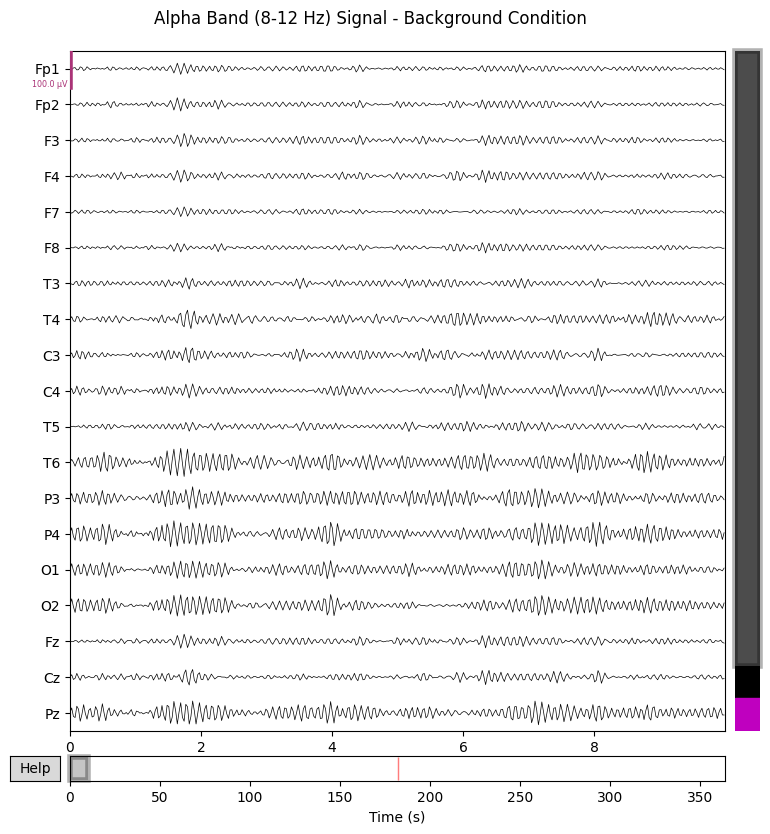

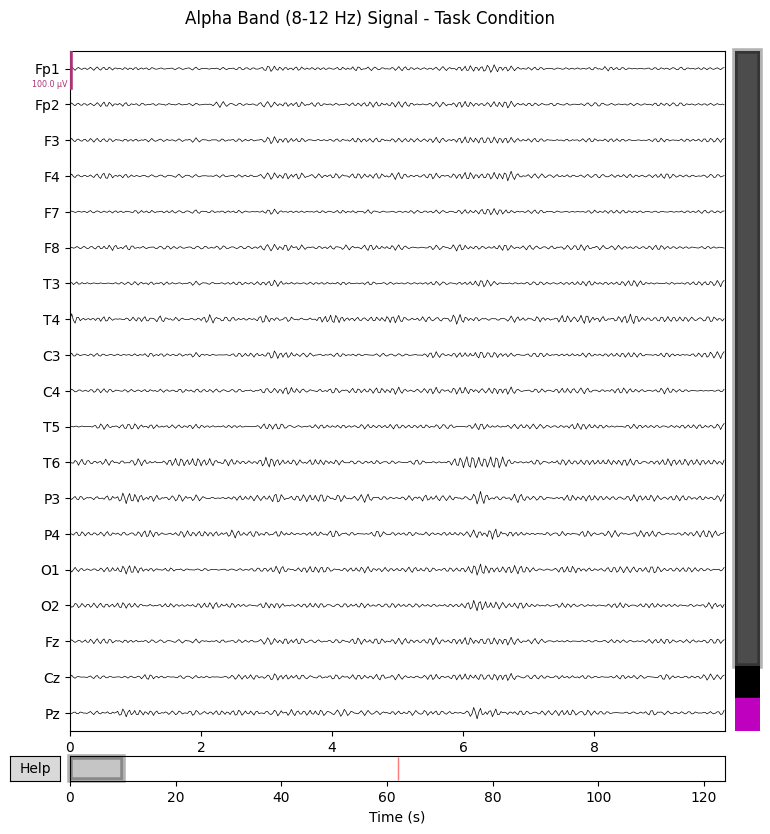

In [ ]:
# To preserve the original data, we work on copies of the raw objects
raw_background_alpha = raw_background.copy()
raw_task_alpha = raw_task.copy()

# Apply a band-pass filter to keep only the 8-12 Hz frequencies.
l_freq = 8.0
h_freq = 12.0
raw_background_alpha.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin')
raw_task_alpha.filter(l_freq=l_freq, h_freq=h_freq, fir_design='firwin')


# Plot the filtered signals for comparison

# Plot the first 10 seconds of the filtered signal for the Background condition.
print("\nPlotting filtered Alpha band signal for Background Condition...")
fig_alpha_bg = raw_background_alpha.plot(
    duration=10,
    n_channels=19,
    scalings=dict(eeg=50e-6), # Scales the y-axis to 50 microvolts
    show=False
)
fig_alpha_bg.suptitle('Alpha Band (8-12 Hz) Signal - Background Condition', y=1.02)


# Plot the first 10 seconds of the filtered signal for the Task condition.
print("Plotting filtered Alpha band signal for Task Condition...")
fig_alpha_task = raw_task_alpha.plot(
    duration=10,
    n_channels=19,
    scalings=dict(eeg=50e-6), # Use the same scaling for fair comparison
    show=False
)
fig_alpha_task.suptitle('Alpha Band (8-12 Hz) Signal - Task Condition', y=1.02)

# Display both plots
plt.show()

## Results interpretation and discussion
- Background Condition : The filtered signal displays large and consistent oscillations. This high amplitude is a direct time-domain representation of the strong, rhythmic alpha activity characteristic of a brain at rest.

- Task Condition : In contrast, the signal's amplitude is dramatically reduced across all channels. The waveforms are much smaller and less prominent, indicating that the alpha rhythm has been significantly weakened.

- Conclusion: The key difference is the marked reduction in signal amplitude during the 'Task' condition. This visually confirms the "Alpha Suppression" phenomenon in the time domain, corroborating the findings from the PSD and spectrogram analyses.

# d) Plot the topomap of average power spectral density in the alpha band(8-12 Hz) for the two conditions


Effective window size : 4.096 (s)
Effective window size : 4.096 (s)


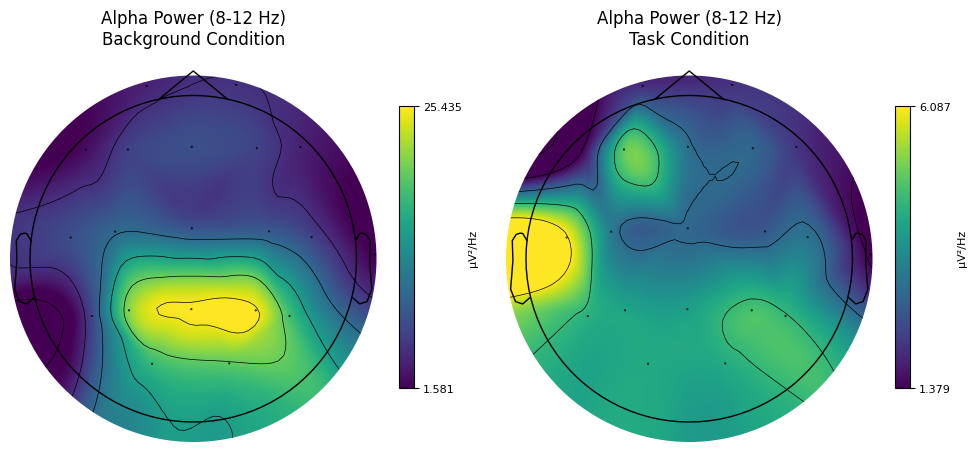

In [ ]:
# Calculate PSD for both conditions
psd_background = raw_background.compute_psd(fmax=50.0)
psd_task = raw_task.compute_psd(fmax=50.0)

# Create a figure with two subplots side-by-side for easy comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot the topomap for the Background condition
psd_background.plot_topomap(
    bands={'Alpha': (8.0, 12.0)},
    ch_type='eeg',
    axes=ax1,
    show=False,
    cmap='viridis'
)
ax1.set_title('Alpha Power (8-12 Hz)\nBackground Condition')

# Plot the topomap for the Task condition
psd_task.plot_topomap(
    bands={'Alpha': (8.0, 12.0)},
    ch_type='eeg',
    axes=ax2,
    show=False,
    cmap='viridis'
)
ax2.set_title('Alpha Power (8-12 Hz)\nTask Condition')

plt.tight_layout()
plt.show()


## Results interpretation and discussion

- Background Condition: The topomap shows high alpha power concentrated over the back of the head. This is the expected spatial pattern for a brain in a relaxed, resting state.

- Task Condition: In contrast, the topomap shows this posterior alpha power has been dramatically suppressed, with the entire scalp now showing low power.

- Conclusion: The key difference is the strong suppression of the posterior alpha rhythm during the task. This analysis adds the final "where" to our findings, spatially confirming that the alpha suppression phenomenon is most prominent over the posterior regions of the head, which were the primary sources of alpha power during rest.